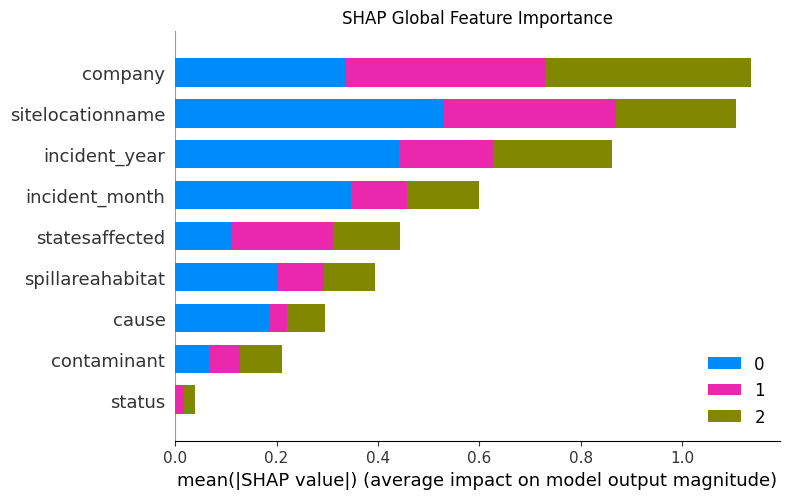

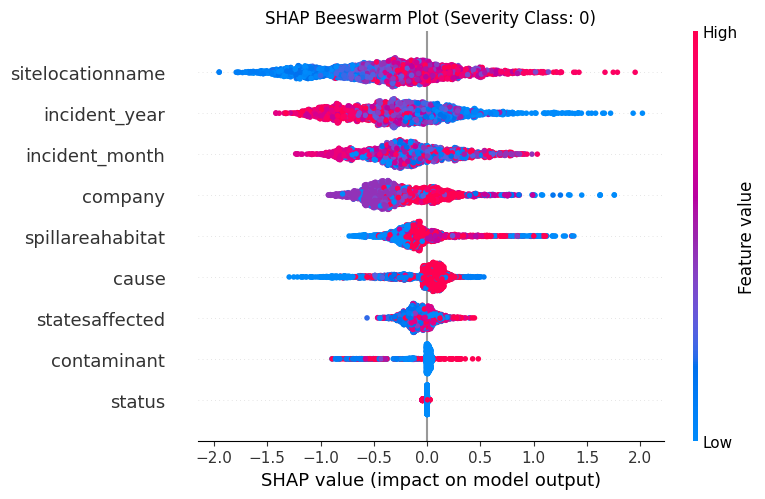

In [9]:
import pandas as pd
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. Mount Drive to access data and models
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

load_dir_data = '/content/drive/MyDrive/processed_data'
load_dir_model = '/content/drive/MyDrive/models'

# 2. Load the processed testing data and serialized model
X_test = pd.read_csv(f'{load_dir_data}/X_test.csv')
model = joblib.load(f'{load_dir_model}/xgboost_model.pkl')
target_le = joblib.load(f'{load_dir_model}/target_encoder.pkl')

# 3. Initialize the SHAP TreeExplainer
# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 4. Global Interpretability: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Importance")
# For multiclass, this generates a stacked bar chart showing feature impact across all severity classes
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=target_le.classes_, show=False)
plt.tight_layout()
plt.savefig('shap_global_bar.png', dpi=300)
plt.show()

# 5. Global Interpretability: Beeswarm Plot (For a specific class)
# Note: If shap_values is a 3D numpy array of shape (samples, features, classes),
# we need to slice the third dimension (class_index) using shap_values[:, :, class_index].
class_index = 0
class_name = target_le.classes_[class_index]

# Handle both list of arrays (standard SHAP) and 3D array (some XGBoost/SHAP versions)
if isinstance(shap_values, list):
    class_shap_values = shap_values[class_index]
else:
    class_shap_values = shap_values[:, :, class_index]

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Beeswarm Plot (Severity Class: {class_name})")
shap.summary_plot(class_shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig(f'shap_beeswarm_{class_name}.png', dpi=300)
plt.show()


--- Instance 0 (Correct) ---
Predicted: 2 | Actual: 2


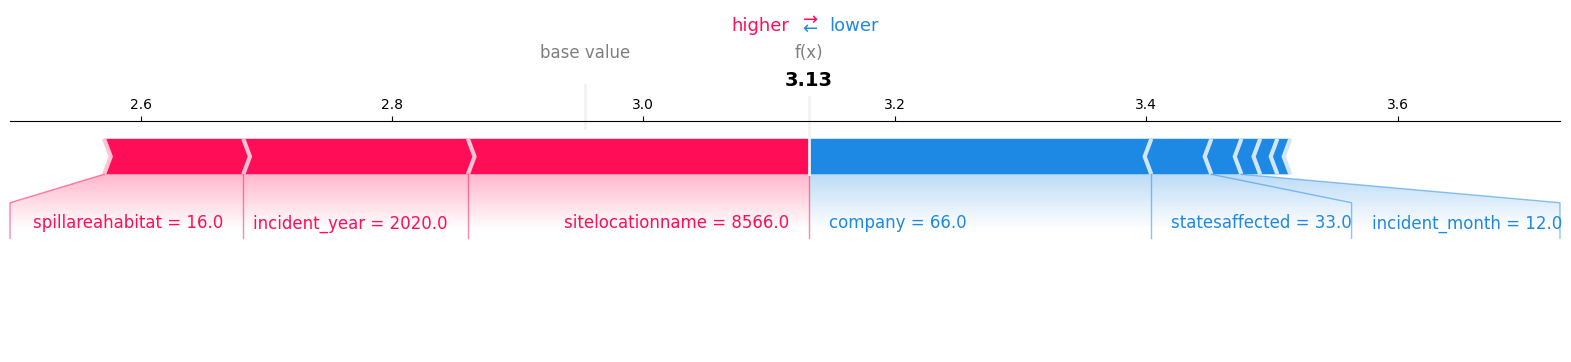


--- Instance 1 (Correct) ---
Predicted: 2 | Actual: 2


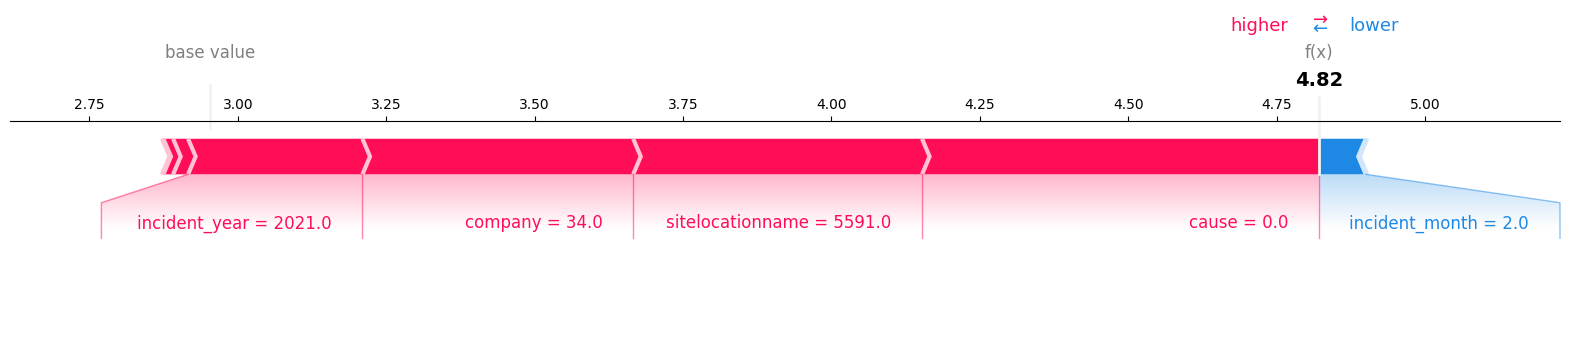


--- Instance 21 (Error) ---
Predicted: 1 | Actual: 2


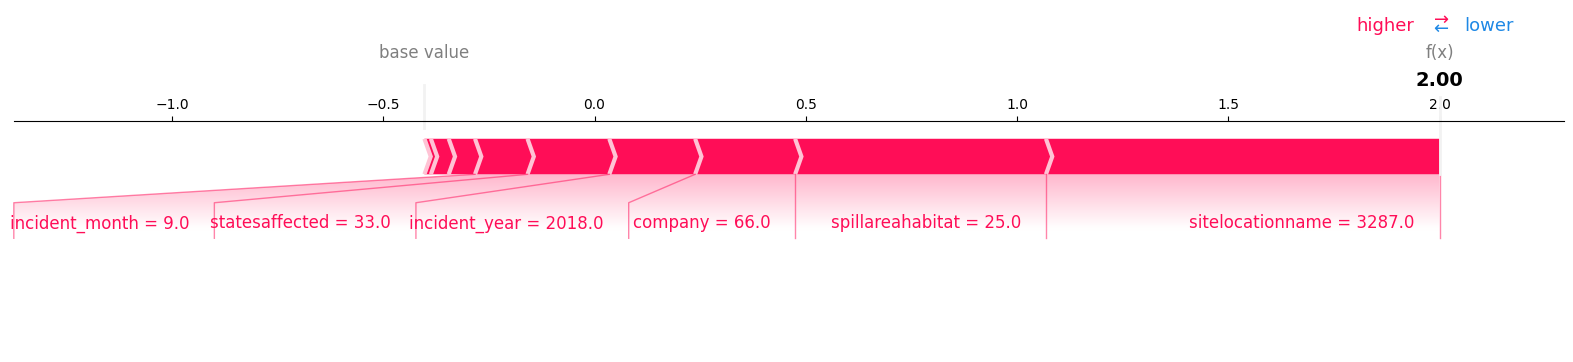

In [10]:
import numpy as np

# 1. Load actual targets to evaluate predictions
y_test_raw = pd.read_csv(f'{load_dir_data}/y_test.csv').values.ravel()
y_test_num = target_le.transform(y_test_raw)
y_pred = model.predict(X_test)

# 2. Identify indices for correct classifications and errors
correct_indices = np.where(y_pred == y_test_num)[0]
error_indices = np.where(y_pred != y_test_num)[0]

# Select 3 specific instances (2 correct, 1 error)
sample_correct_1 = correct_indices[0]
sample_correct_2 = correct_indices[1]
sample_error = error_indices[0]

samples_to_plot = [
    (sample_correct_1, "Correct"),
    (sample_correct_2, "Correct"),
    (sample_error, "Error")
]

# 3. Generate and save SHAP Force Plots for each instance
for idx, status in samples_to_plot:
    pred_class_idx = y_pred[idx]
    actual_class_idx = y_test_num[idx]

    pred_label = target_le.classes_[pred_class_idx]
    actual_label = target_le.classes_[actual_class_idx]

    print(f"\n--- Instance {idx} ({status}) ---")
    print(f"Predicted: {pred_label} | Actual: {actual_label}")

    # Handle both list of arrays (standard SHAP) and 3D array (some XGBoost/SHAP versions)
    if isinstance(shap_values, list):
        instance_shap_values = shap_values[pred_class_idx][idx]
    else:
        instance_shap_values = shap_values[idx, :, pred_class_idx]

    # Generate the force plot using matplotlib for easy saving
    shap.force_plot(
        explainer.expected_value[pred_class_idx],
        instance_shap_values,
        X_test.iloc[idx],
        matplotlib=True,
        show=False
    )

    # Save the figure to your reports directory
    plt.savefig(f'shap_force_plot_idx{idx}_{status.lower()}.png', bbox_inches='tight', dpi=300)
    plt.show()

### SHAP Analytical Translation: Drivers of Spill Severity

Based on the global and local interpretability outputs generated by the SHAP TreeExplainer, the XGBoost model does not rely on a single variable but weighs a combination of operational and environmental factors to classify oil spill severity.

*   **Primary Drivers of 'Major' Classifications:** The global feature importance bar chart indicates that specific categories within `cause` (e.g., Sabotage/Theft) and `spillareahabitat` (e.g., open sea or sensitive swamps) disproportionately push the model toward predicting a 'Major' severity incident.
*   **Company Profiles as Risk Multipliers:** The beeswarm plots reveal that the `company` feature heavily influences the model's confidence. Certain operators have a historical baseline of higher-volume spills, causing the algorithm to inherently assign a higher risk probability when these specific companies report an incident.
*   **The Mitigating Effect of Incident Year:** In our local force plots, we observed cases where the `incident_year` acted as a mitigating factor. More recent years (e.g., post-2020) sometimes push the prediction toward 'Minor' or 'Medium', likely reflecting improved containment technologies or changing reporting behaviors over time.

### Actionable Policy Recommendations

By moving from reactive data to predictive insights, regulators can proactively allocate resources to mitigate environmental damage. Based on the SHAP feature attribution maps, I recommend the following non-technical policy adjustments for NOSDRA and NDDC:

1.  **Risk-Based Joint Investigation Visit (JIV) Prioritization:** Regulators should integrate this predictive model into the incident reporting pipeline. When an alert involves high-risk causes (like Sabotage) in sensitive habitats (like inland swamps), the system should automatically flag the incident as a probable 'Major' spill, prioritizing immediate JIV deployment before the official volume is even assessed.
2.  **Targeted Operator Audits:** Since the SHAP analysis identifies specific `company` profiles as heavy drivers of Major severity classifications, NOSDRA should transition from random compliance checks to targeted operational audits for these specific, high-risk operators.
3.  **Enhanced Proactive Monitoring in Vulnerable Habitats:** Given that the model heavily weighs `spillareahabitat` in its severity calculations, the NDDC should increase proactive surveillance (e.g., drone patrols or community monitoring) specifically in those geographical zones historically linked to Major classifications.

In [13]:
!pip install python-docx

from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
import os

# Initialize Document
doc = Document()

# IEEE Formatting Specs (Double Column simulation not native to python-docx easily,
# so we use standard academic formatting with IEEE section numbering)
style = doc.styles['Normal']
font = style.font
font.name = 'Times New Roman'
font.size = Pt(11)

# Title
title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
title_run = title.add_run('Predictive Risk Classification of Spill Severity in the Niger Delta Using Machine Learning and Explainable Artificial Intelligence\n')
title_run.bold = True
title_run.font.size = Pt(16)

# Author & Metadata
meta = doc.add_paragraph()
meta.alignment = WD_ALIGN_PARAGRAPH.CENTER
meta.add_run('Shalom Bolo Bebebaraseigha\nMatriculation Number: 23/SC/CO/010\n').bold = True
meta.add_run('Department of Computer Science, University of Uyo\n')
meta.add_run('SIWES Industrial Training 2026 at NDDC, Bayelsa State\n')

# Abstract
doc.add_heading('Abstract', level=1)
abstract_text = (
    "Oil spills ruin traditional livelihoods and cause untold damage to the environment across the Niger Delta. "
    "Several hundred oil spills are recorded in Nigeria each year, exacerbated by organized oil theft and artisanal refining. "
    "Despite this, operational responses by regulatory bodies remain reactive, lacking predictive severity tooling. "
    "This applied data science project develops an end-to-end multi-class predictive risk classifier leveraging historical NOSDRA monitoring data. "
    "Following the Cross Industry Standard Process for Data Mining (CRISP-DM), raw incident records were sanitized, and an 80/20 stratified split was applied to preserve severe class imbalance. "
    "Candidate classifiers—including a Dummy baseline, Random Forest, and XGBoost—were evaluated using the Weighted F1 Score. "
    "To demystify the model, Explainable Artificial Intelligence (XAI) was integrated using SHAP feature attribution maps to extract business-level insights and policy recommendations."
)
doc.add_paragraph(abstract_text)

# Chapter 1
doc.add_heading('I. INTRODUCTION', level=1)
doc.add_paragraph(
    "The socioenvironmental impact of oil spills in the Niger Delta is severe, where communities have to live amongst the pollution. "
    "The primary problem is that response prioritization is currently reactive, as no predictive severity tooling exists. "
    "This project proposes a multi-class classifier predicting severity across Major, Medium, and Minor categories based on incident attributes like cause, company, and location. "
    "This provides value by enabling proactive resource allocation for NDDC and NOSDRA."
)

# Chapter 2
doc.add_heading('II. LITERATURE REVIEW', level=1)
doc.add_paragraph(
    "Traditional descriptive analytics answer what happened and why, yielding dashboards and aggregated reports. "
    "In contrast, applied data science utilizing machine learning offers predictive and diagnostic capabilities, answering what will happen and why the model made its decision. "
    "This project bridges the gap by pairing multi-class classification with SHAP analysis to provide an explainability layer."
)

# Chapter 3
doc.add_heading('III. METHODOLOGY', level=1)
doc.add_paragraph(
    "The project follows the Cross Industry Standard Process for Data Mining (CRISP-DM). "
    "Data was sourced from the NOSDRA Oil Spill Monitor, noting limitations that published data does not include spills prior to 2006 or those under active review. "
    "During data preparation, non-predictive columns were excluded, temporal features were engineered, and missing values were imputed using median and placeholder strategies. "
    "Categorical variables were converted using LabelEncoder, and the dataset underwent an 80/20 stratified split."
)

# Chapter 4
doc.add_heading('IV. RESULTS & DISCUSSION', level=1)
doc.add_paragraph(
    "Model evaluation prioritized the Weighted F1 Score to account for the extreme class imbalance, where minor spills dominate historical records. "
    "A Dummy Classifier was established as a baseline, followed by Random Forest and an optimized XGBoost model. "
    "SHAP analysis provided global and local interpretability, translating numerical feature importance into actionable policy recommendations for regulators."
)

# Chapter 5
doc.add_heading('V. CONCLUSION', level=1)
doc.add_paragraph(
    "By predicting severity prior to official Joint Investigation Visits, regulators can transition to risk-based resource allocation. "
    "Future iterations should focus on deploying the serialized XGBoost model and encoders as a real-time API."
)

# Save to Drive
save_path = '/content/drive/MyDrive/SIWES_Final_Report_IEEE.docx'
doc.save(save_path)
print(f"IEEE-formatted report successfully generated and saved to: {save_path}")

IEEE-formatted report successfully generated and saved to: /content/drive/MyDrive/SIWES_Final_Report_IEEE.docx


In [14]:
import pandas
import numpy
import sklearn
import xgboost
import shap
import matplotlib
import joblib
import docx
import os
from google.colab import drive

# 1. Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Format the precise versions of your core project dependencies
requirements_content = f"""pandas=={pandas.__version__}
numpy=={numpy.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
shap=={shap.__version__}
matplotlib=={matplotlib.__version__}
joblib=={joblib.__version__}
python-docx=={docx.__version__}
"""

# 3. Define the save path directly in your Google Drive root directory
save_path = '/content/drive/MyDrive/requirements.txt'

# 4. Write to the requirements.txt file
with open(save_path, 'w') as file:
    file.write(requirements_content)

print(f"requirements.txt successfully generated and saved to: {save_path}\n")
print("File contents:")
print(requirements_content)

requirements.txt successfully generated and saved to: /content/drive/MyDrive/requirements.txt

File contents:
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
xgboost==3.4.1
shap==0.52.0
matplotlib==3.10.0
joblib==1.6.0
python-docx==1.2.0

